## Лабораторна робота №3.
***Data Pre-Processing***

Оцінювання даної роботи буде ураховувати якість ваших візуалізацій (вони можуть незначно відрізнятися від прикладів, але повинні змістовно відображати суть задачі) та опис отриманих вами результатів. При наявності ЛИШЕ візуалізацій без роз'яснень, робота оцінюватися НЕ БУДЕ.

Під час виконання вам дозволено користуватися будь-якими зручними для вас бібліотеками для візуалізації.

Роботи ідентифіковані як ІДЕНТИЧНІ одразу отримують 0 балів.

Для виконання цієї лабораторної роботи Вам необхідно скористатися вибіркою [titanic.csv](https://gist.github.com/michhar/2dfd2de0d4f8727f873422c5d959fff5).  
Цей датасет ви вже використовували в лабораторній роботі №1 ;)  
  
  ```NB:побудовані графіки та гістограми мають бути змістовними і візуально зрозумілими.```

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency


sns.set(style="whitegrid")
sns.set_context('talk')

***Завдання 1.*** Перед початком роботи з будь яким датасетом, необхідно:  
- завантажити датасет;  
- вивести основну статистичну інформацію по числовим змінним;
- вивести розмірність датасету;
- перевірити типи змінних і кількість данних по кожній змінній.

In [31]:
dataset = pd.read_csv("/content/titanic.csv")
print(dataset.describe(),'\n')
print(dataset.shape,'\n')
print(dataset.info(),'\n')

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200   

(891, 12) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to

***Завдання 2.*** Визначити кількість пропущених значень по кожному атрибуту

In [35]:
print(dataset.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Ваші висновки:

***Завдання 3:*** Побудувати матрицю кореляції

*текст курсивом*

1.   Вирахувати кореляційні коефіціенти для набору данних за методом Пірсона
2.   Відобразити отриману матрицю коефіціентів у вигляді теплокарти

3. Описати отримані результати, спираючись на значення коефіціентів кореляції



             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


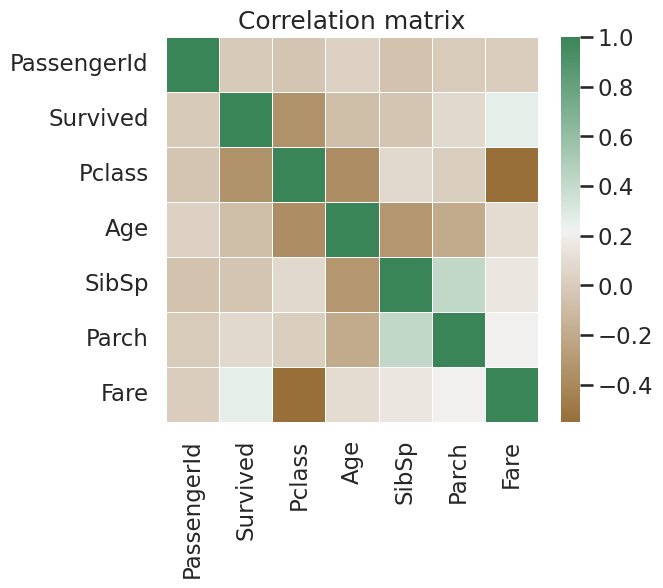

In [33]:
correlation_matrix_titanic = dataset.corr(method='pearson', numeric_only=True)
print(correlation_matrix_titanic)

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix_titanic,cmap=sns.diverging_palette(50, 500, n=500), fmt='.2f', linewidths=0.5, )
plt.title('Correlation matrix')
plt.show()


1. Можна спостерігати взаємозв'язок виживанням та класом, вони мають коефіцієнт кореляції = -0.338. Коефіцієнт кореляції негативний тому, пасажири з квитком першого класу мали більгий шанс на виживання ніж з квитком третього класу.

2. Взаємозв'язок між виживанням і статтю, коефіцієнт кореляції = 0.543. З цього можна дійти висновку, що стать мала позитивний вплив на виживання, та скоріше всього жінки мали більший шанс на виживання ніж чоловіки.

3. Взаємозв'язок між виживанням і вартістю квитка, коефіцієнт кореляції = 0.257. Це вказує на те, що пасажири з дорожчими квитками мали вищий шанс вижити, що, пов’язано з квитками першого класу.

4. Взаємозв'язок між виживанням і віком, коефіцієнт кореляції = -0.0649. Це свідчить про слабкий негативний вплив віку на виживання, тобто молодші пасажири мали трохи вищий шанс вижити, але загалом вік не був визначальним фактором.

5. Взаємозв'язок між віком і розміром сім’ї, коефіцієнт кореляції = -0.2456. Це означає, що молодші пасажири частіше подорожували у більших сім’ях, тоді як старші пасажири подорожували самостійно або з меншою кількістю родичів.

6. Взаємозв'язок між класом і вартістю квитка, коефіцієнт кореляції = -0.549. Це сильна негативна кореляція, яка свідчить про те, що квитки першого класу були значно дорожчими за квитки третього класу.
'



```
# Має бути у форматі коду
```

**Завдання 4:** Як ви могли помітити, у нашому датесеті досить багато пропущених значень, зокрема у атрибута віку пасажирів. Робота з такими даними впливае як на результат моделювання так і на загалом уявлення цілісної картини про дані. Тож для того, що позбавитися пропусків ми використаємо заповнення пропущених значень медіаною за групами.



1.   Напишіть функцію, що на вхід приймає датафрейм, назву колонки з пропущеними значеннями та список групуючих колонок та повертає датафрейм з заповненими пропущеними значеннями
2.   Наведіть приклад роботи функції та зробіть перевірку на пропущені значення (дивись **завдання 2**)



In [34]:
def fill_null_values(dataframe,column_null,group_columns):
  fill_null = dataframe.groupby(group_columns)[column_null].transform('median')
  dataframe[column_null] =dataframe[column_null].fillna(fill_null)
  return dataframe

dataset_filled = fill_null_values(dataset,"Age", "Survived")
print(dataset_filled)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

Ми позбулись нульових значень в 'Age' колонці, і замінили їх на значення з медіани.


***Завдання 5:*** В моделях машинного навчання інснує велика проблема опрацювання безперервних змінних. Потрібно перетворити безперервні значення в категоріальні.

Максимальний вік пасажира - ```80 років```.

Отже, давайте розділимо діапазон від ```0 до 80``` на ```5``` осередків.


Додайте до нашого датасету нову колонку ```Age_bin```, в якій будуть значення ```0, 1, 2, 3, 4```відповідно кожній віковій групі.

Побудуйте графік, який відображає кількість виживших у кожній віковій категорії.





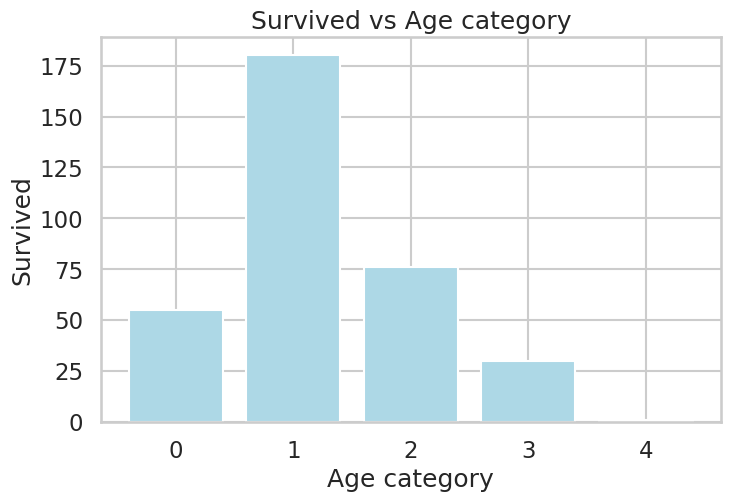

In [36]:
dataset["Age_bin"] = pd.cut(dataset["Age"], bins=np.linspace(0, 80, 6), labels=[0, 1, 2, 3, 4])

survival_counts = dataset[dataset["Survived"] == 1]["Age_bin"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(survival_counts.index, survival_counts.values, color='LightBlue')
plt.xlabel("Age category")
plt.ylabel("Survived")
plt.title("Survived vs Age category")
plt.show()


1. Найбільше шансів на виживання мали люди в категорії 1, що є переважно молоді люди.
2. Люди категорії 2 теж мали відносно середні шанси на виживання
3. Також, діти з категорії 0 мали високі шанси на виживання, так як вони скоріше всього були пріорітетом.
4. На жаль, люди в категорії 3 і 4 мали зовсім малі шанси.

***Завдання 6:*** Так як змінна ```fare``` також є неперервною її треба закодувати до ```порядкової шкали```
Для цього скоритайтесь функцією ```pandas.qcut```.
[pandas.qcut](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html)  
- необхідно перевірити, чи є вірною гіпотеза про те, що кількість виживших пасажирів для квартильних значеннь змінної ```fare``` відрізняється, та чи доцільно використовувати кодування на цю змінну(для подальшої роботи з закодованою фичею)

In [37]:
fare_scale= pd.qcut(dataset['Fare'], q=3, labels=[1, 2, 3])
print(fare_scale)

fare_survivor_table = pd.crosstab(fare_scale, dataset['Survived'])
print(fare_survivor_table)

fare_survivot_chisquare = chi2_contingency(fare_survivor_table)
print(fare_survivot_chisquare)

0      1
1      3
2      1
3      3
4      1
      ..
886    2
887    3
888    2
889    3
890    1
Name: Fare, Length: 891, dtype: category
Categories (3, int64): [1 < 2 < 3]
Survived    0    1
Fare              
1         247   61
2         172  116
3         130  165
Chi2ContingencyResult(statistic=83.79812453125032, pvalue=6.36016615023576e-19, dof=2, expected_freq=array([[189.77777778, 118.22222222],
       [177.45454545, 110.54545455],
       [181.76767677, 113.23232323]]))


1. Гіпотеза про те, що кількість виживших пасажирів для квартильних значень змінної fare відрізняється, є вірною. Результати показують statistic = 83.8, p-value = 6.36e-19, що є статистично значуща залежність між значенням вартості квитка та ймовірністю виживання. Тому можна стверджувати, що різні рівні вартості квитка справді впливають на ймовірність виживання.
2. Кодування змінної fare до порядкової шкали є доцільним для подальшої роботи з моделлю. Оскільки вартості квитків мають явний вплив на ймовірність виживання, використання закодованої версії цієї змінної дозволить моделі краще враховувати цей фактор.

***Завдання 7:*** Необхідно створити нові змінні ```Family_size``` та ```Alone``` та проаналізувати їх. Змінна ```Family_size``` передає суму змінних ```Parch``` та ```SibSp```. Змінна ```Family_size``` буде відібражати комбіновані дані, які необхідні для перевірки гіпотези, що ```виживання пасажирів залежіть від кількості членів їх сім'ї```. Змінна ```Alone``` позначає наявніть сім'ї.

In [38]:
dataset['Family_size'] = (dataset['Parch']+dataset['SibSp'])
print(dataset['Family_size'].head(10))

dataset['Alone'] = np.where(dataset['Family_size'] > 0, '1', '0')
print(dataset['Alone'].head(10))

0    1
1    1
2    0
3    1
4    0
5    0
6    0
7    4
8    2
9    1
Name: Family_size, dtype: int64
0    1
1    1
2    0
3    1
4    0
5    0
6    0
7    1
8    1
9    1
Name: Alone, dtype: object


Ми успішно створили колонки з розміром сім'ї та чи мала людина сім'ю на борту. Це дає нам можливіть робити подальші аналізи з урахуванням цієї інформації

***Завдання 8:*** Видалити атрибути які є ***НЕрелевантними*** або містять багато пропущених значень. Аргументувати свій вибір.

In [39]:
dataset = dataset.drop(columns=['PassengerId', 'Cabin','SibSp','Parch','Ticket'])
print(dataset)

     Survived  Pclass                                               Name  \
0           0       3                            Braund, Mr. Owen Harris   
1           1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2           1       3                             Heikkinen, Miss. Laina   
3           1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4           0       3                           Allen, Mr. William Henry   
..        ...     ...                                                ...   
886         0       2                              Montvila, Rev. Juozas   
887         1       1                       Graham, Miss. Margaret Edith   
888         0       3           Johnston, Miss. Catherine Helen "Carrie"   
889         1       1                              Behr, Mr. Karl Howell   
890         0       3                                Dooley, Mr. Patrick   

        Sex   Age     Fare Embarked Age_bin  Family_size Alone  
0      male  22.0   7.

1. PassengerId, я вирішила видалити цей стовчик, тому що він ніяк не впливає на аналіз і коли виводиш датасет утворюються автоматичні id для кожного рядка
2. Cabin, велика кількість пропущених значень, більше ніж половина.
3. SibSp,Parch, так як ми створили окрему колонку з розміром сім'ї нам не знадобляться ці дві колонки.
4. Ticket, просто id квитка, що не має впливу ні на які фактори.

***Завдання 9:*** Перетворіть змінні ```Sex```, ```Embarked``` та ```Title``` в числові значення


In [40]:
dataset['Title']=dataset['Name'].str.extract(r',\s([A-Za-z]+)\.')
dataset['Title'] = pd.factorize(dataset['Title'])[0]
print(dataset['Title'])

dataset['Sex'] = dataset['Sex'].map({'male':0,'female':1})
print(dataset['Sex'])

dataset['Embarked'] = dataset['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
print(dataset['Embarked'])

0      0
1      1
2      2
3      1
4      0
      ..
886    5
887    2
888    2
889    0
890    0
Name: Title, Length: 891, dtype: int64
0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    1
889    0
890    0
Name: Sex, Length: 891, dtype: int64
0      0.0
1      1.0
2      0.0
3      0.0
4      0.0
      ... 
886    0.0
887    0.0
888    0.0
889    1.0
890    2.0
Name: Embarked, Length: 891, dtype: float64


Було успішно перетворено в числові значення.


***Завдання 10.*** Побудувати графіки всіх категоріальних змінних та проаналізувати скільки кожна категорія містить даних

1.   виділити категоріальні змінні
2.   побудувати сітку графіків кількості спотрережень по кожній категорії



     Survived  Pclass                                               Name  Sex  \
0           0       3                            Braund, Mr. Owen Harris    0   
1           1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1   
2           1       3                             Heikkinen, Miss. Laina    1   
3           1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1   
4           0       3                           Allen, Mr. William Henry    0   
..        ...     ...                                                ...  ...   
886         0       2                              Montvila, Rev. Juozas    0   
887         1       1                       Graham, Miss. Margaret Edith    1   
888         0       3           Johnston, Miss. Catherine Helen "Carrie"    1   
889         1       1                              Behr, Mr. Karl Howell    0   
890         0       3                                Dooley, Mr. Patrick    0   

      Age     Fare  Embarke

<ipython-input-41-526027f55a51>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataset[column], palette='Pastel1')


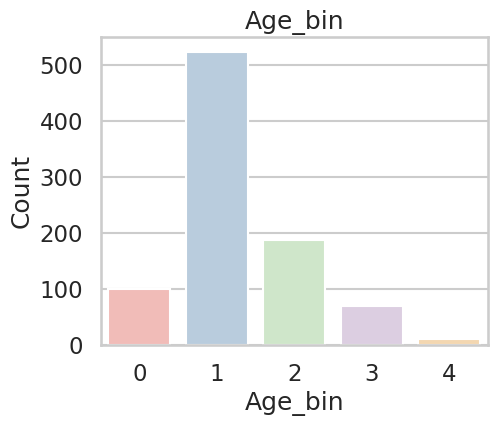

<ipython-input-41-526027f55a51>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataset[column], palette='Pastel1')


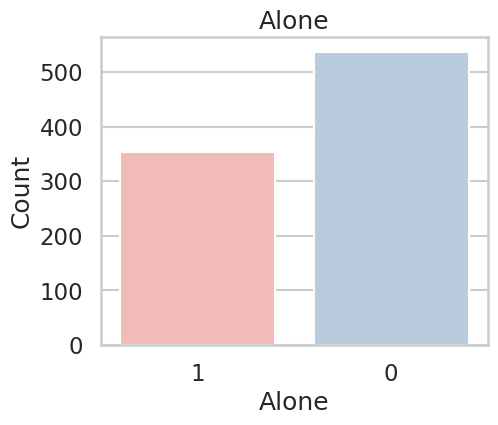

In [41]:
print(dataset)
dataset = dataset.drop(columns=['Name'])


categorical_columns = dataset.select_dtypes(include=['object','category']).columns
print(categorical_columns)

for column in categorical_columns:
    plt.figure(figsize=(5, 4))
    sns.countplot(x=dataset[column], palette='Pastel1')
    plt.title(f"{column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()

1. На першому графіку спостерігається значна нерівномірність у розподілі значень. Найбільше значень у категорії 1, а категорія 4 містить найменше значень. Інші категоріальні змінні можуть мати подібну.
2. Більшість спостережень припадає на категорію 0, тобто,люди, які подорожували не одні. Можна зробити аналіз виживаності, чи є залежність між тим, чи був пасажир сам, і його шансами на виживання.

***Завдання 11.*** Побудувати діаграми розподілу всіх числових змінних

Index(['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Family_size',
       'Title'],
      dtype='object')


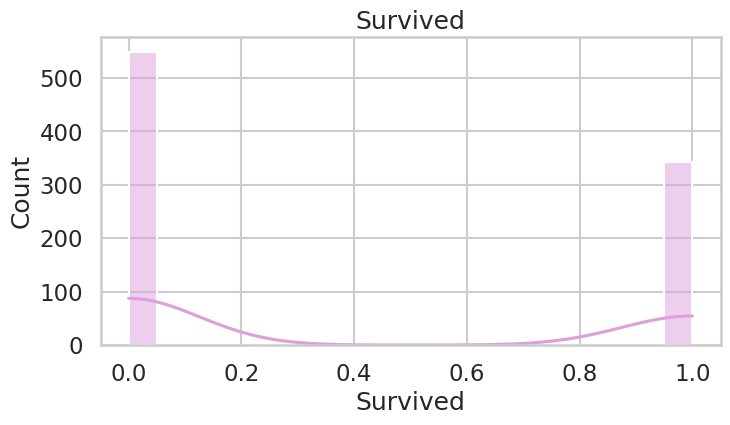

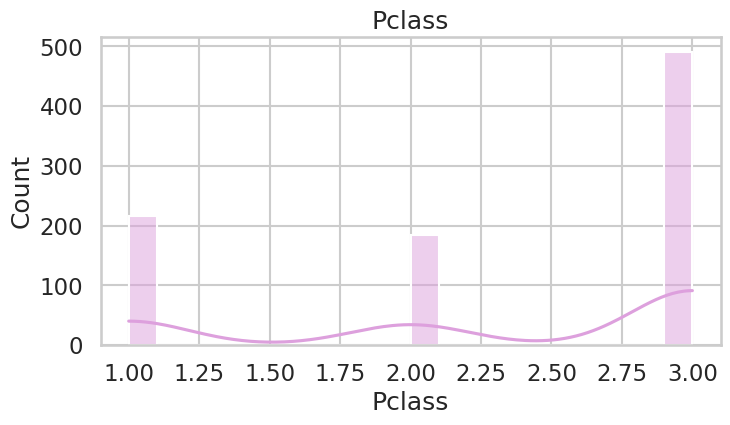

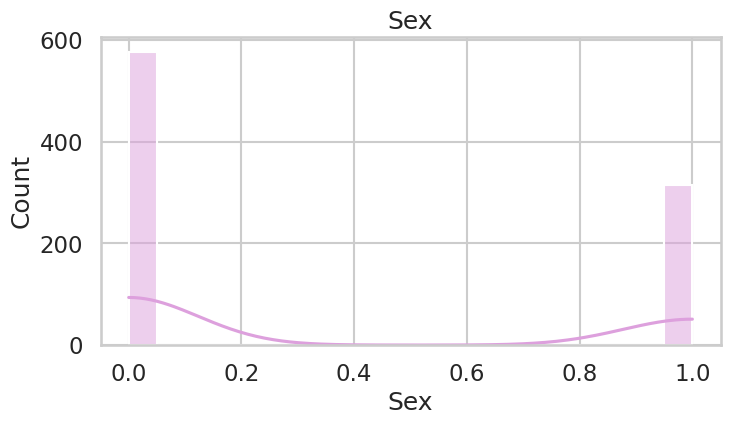

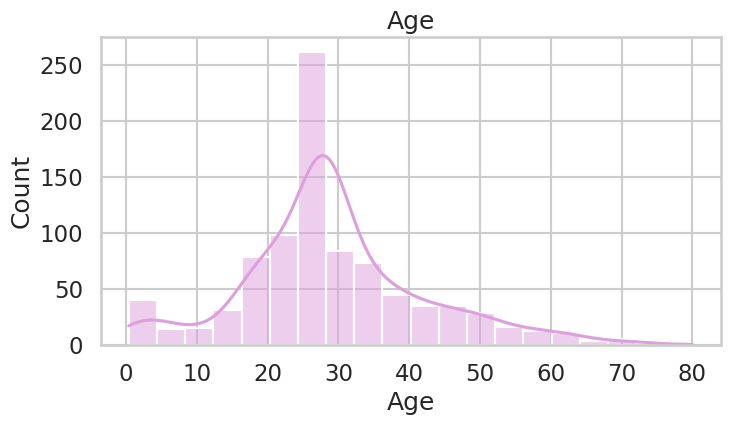

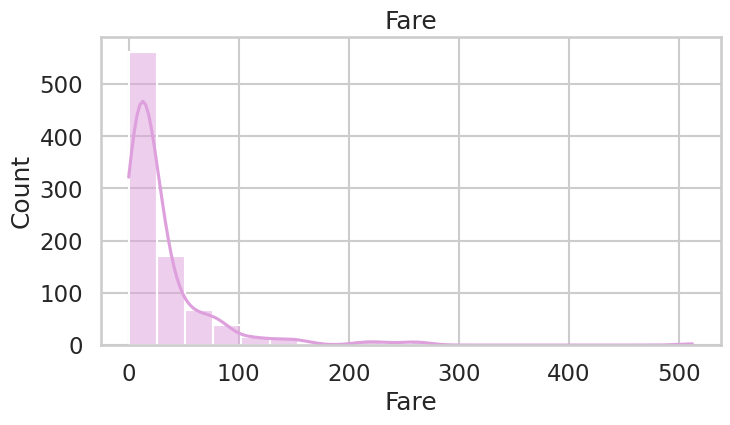

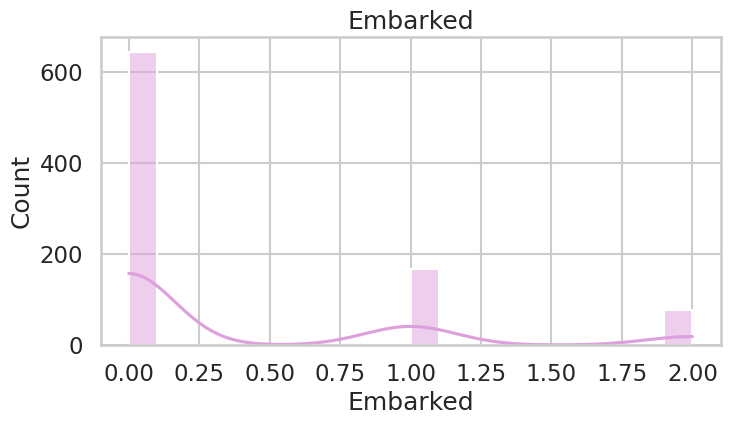

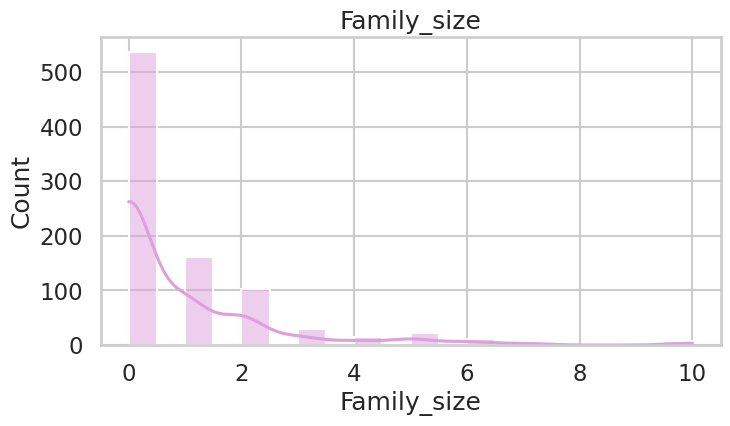

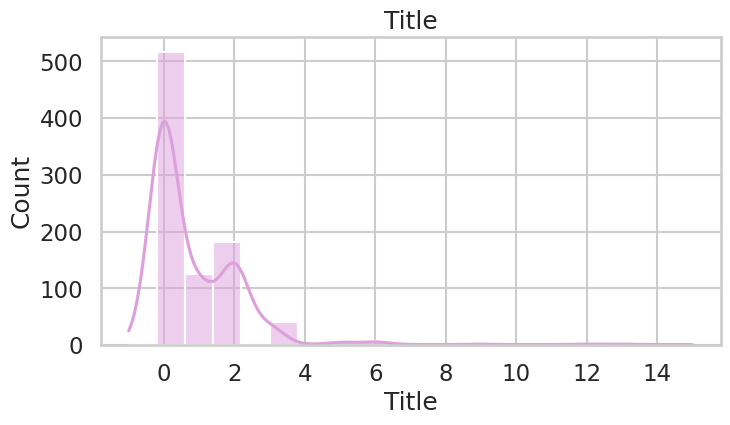

In [42]:
numerical_columns = dataset.select_dtypes(include=['int','float']).columns
print(numerical_columns)

for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(dataset[column], kde=True, bins=20, color='Plum')
    plt.title(f"{column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()

1. Майже в два рази більше людей померло ніж вижило.
2. Найбільше людей мали квиток третього класу.
3. На борту було в два рази більше чоловіків ніж жінок.
4. Розподіл приблизно нормальний, з найбільше людей між 20-30 роками.
5. Більшість значень близькі до нуля, тоді як є кілька значно вищих значень.
6. Найбільше людей сідалм на порті першої категорії. і набагато менше в інших двох.
7. Більшість людей на борту мають маленький розмір сім’ї або зовсім без неї.Є значно менше спостережень із великими сім’ями.
8. Більшість спостережень належить до невеликої кількості унікальних титулів.

##Співвіднонешшя між всіма числовими змінними
  
***Завдання 12.*** В деяких випадках візуалізація співвідношення між змінними (числовими, категоріальними) дає можливість побачити викиди в змінних та знайти приховані тенденції і виділити навіть додаткові змінні. Тому, необхідно:
1) побудувати графіки співвідношення між всіма числовими змінними.  
2) описати отримані співвідношення і запропонувати як їх можна (чи не можна) використати

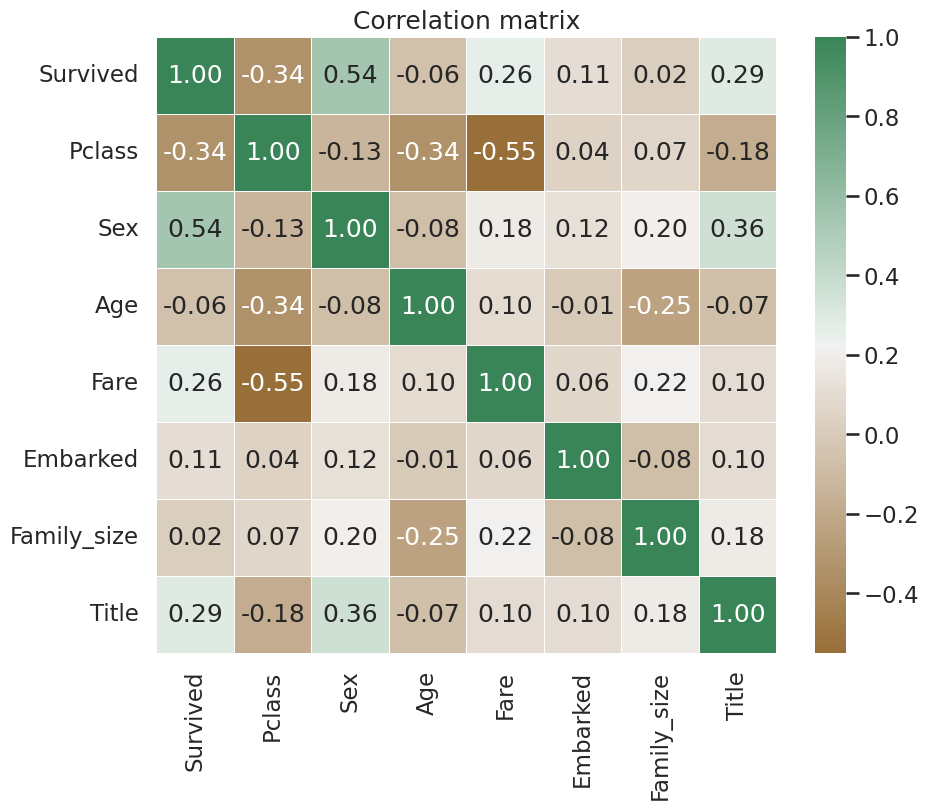

In [43]:
numeric_dataset = dataset.select_dtypes(include=['float', 'int'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_dataset.corr(), annot=True, cmap=sns.diverging_palette(50, 500, n=500), fmt=".2f", linewidths=0.5)
plt.title("Сorrelation matrix")
plt.show()


1. Взаємозв'язок між виживанням і пасажирським класом, коефіцієнт кореляції = -0.340. Пасажири вищого класу мали значно вищі шанси на виживання, тоді як пасажири третього класу – найнижчі. Клас можна ефективно використовувати у передбаченні і прогнозуванні виживання.

2. Взаємозв'язок між виживанням і статтю,коефіцієнт кореляції = 0.543.Жінки мали значно вищі шанси на виживання, що відповідає історичному принципу "жінки та діти першими". Стать є важливою змінною для передбачення виживаності та обов’язково має бути включений у модель.

3. Взаємозв'язок між виживанням і вартістю квитка,коефіцієнт кореляції = 0.260
Пасажири з дорожчими квитками мали вищі шанси на виживання, також можна помітити, що вони переважно подорожували у першому класі.Ця змінна може бути корисною.

4. Взаємозв'язок між виживанням і титулом,коефіцієнт кореляції = 0.290. Соціальний статус впливав на шанси виживання, що може бути пов’язано з доступом до ресурсів та поведінкою під час евакуації.Титул можна використовувати для прогнозування виживаності, особливо якщо категорії титулів згрупувати у більші групи.

5. Взаємозв'язок між пасажирським класом і вартістю квитка,коефіцієнт кореляції = -0.550. Сильний негативний зв’язок – чим нижчий клас, тим дешевший квиток.
Одна з цих змінних може бути виключена з моделі, щоб уникнути мультиколінеарності.

6. Взаємозв'язок між віком і розміром сім'ї,коефіцієнт кореляції = -0.250 Молодші пасажири частіше подорожували великими сім’ями, тоді як старші пасажири були більш схильні подорожувати самостійно. Цей фактор може бути корисним, особливо якщо перевірити його взаємозв’язок із виживанням.

Кожне правильно виконане завдання буде оцінюватись в ```2 бали```.